Saved iowa_dynamic_yield_by_day.csv — sample:
      date  year  doy  observed_to_date_multiplier  expected_future_multiplier_by_doy  forecast_multiplier  predicted_yield_bu_ac
2010-05-01  2010  121                          1.0                           0.256132             0.256132              43.841974
2010-05-02  2010  122                          1.0                           0.224126             0.224126              43.361894
2010-05-03  2010  123                          1.0                           0.225314             0.225314              43.379706
2010-05-04  2010  124                          1.0                           0.226591             0.226591              43.398862
2010-05-05  2010  125                          1.0                           0.227693             0.227693              43.415394
2010-05-06  2010  126                          1.0                           0.228812             0.228812              43.432184
2010-05-07  2010  127                       

C:\Users\Airly\AppData\Local\Temp\ipykernel_3980\2172631637.py:215: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(years_plot))


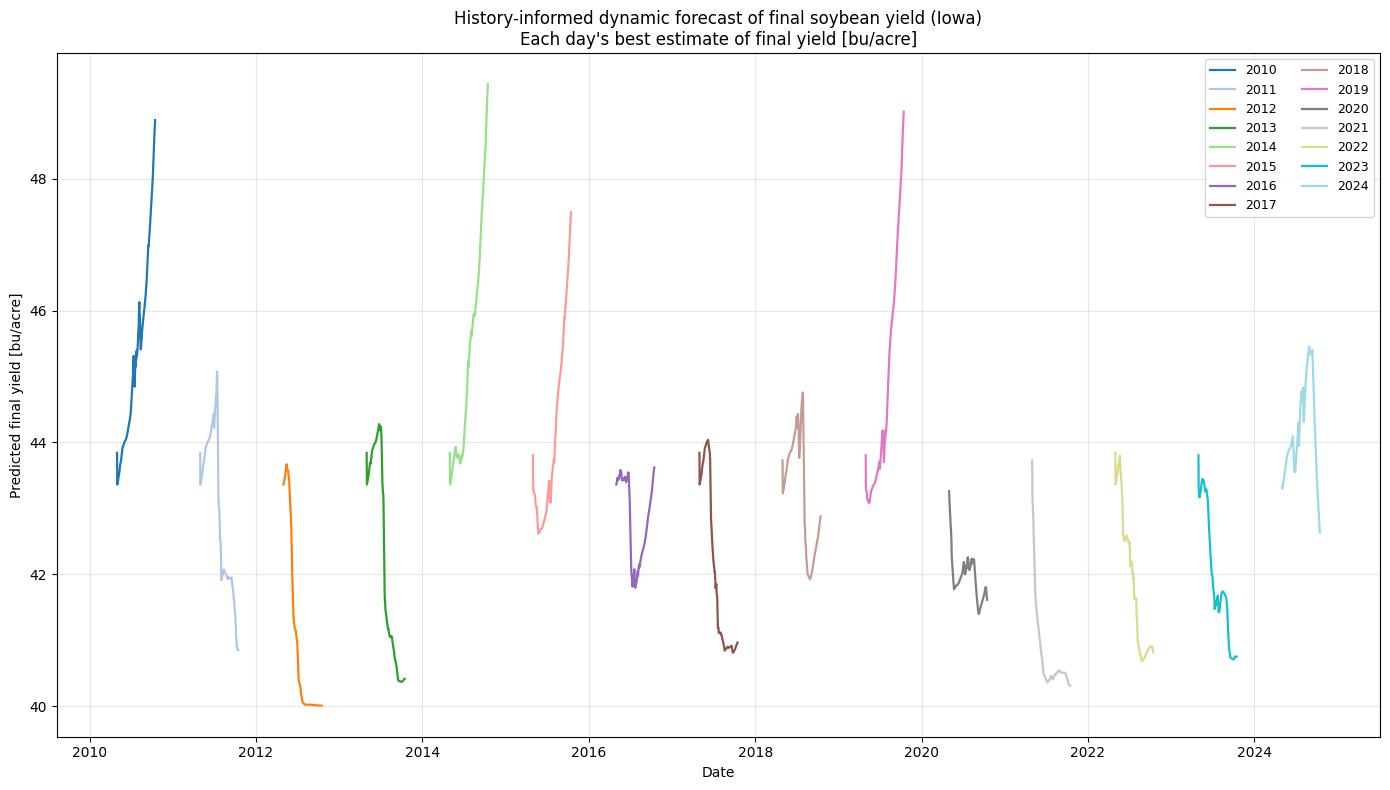

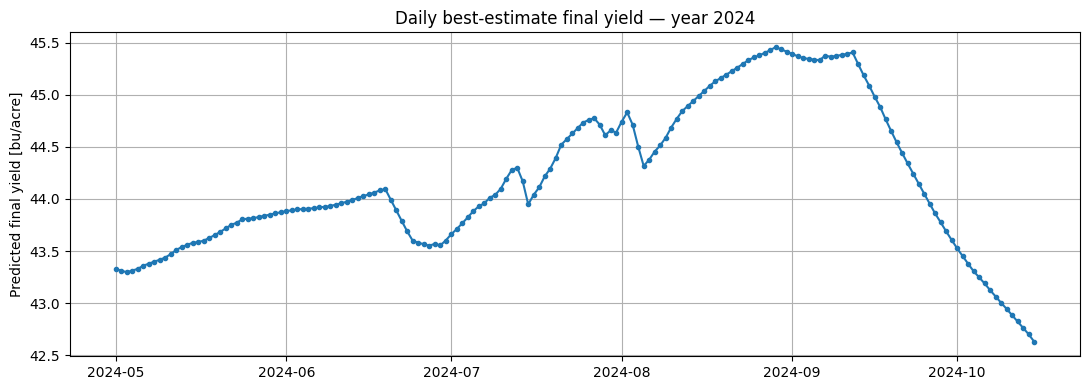

In [17]:
#!/usr/bin/env python3
"""
History-informed dynamic daily yield multiplier forecast (Iowa)
- Input CSV must have columns: time, tmin, tmax, prcp (prcp used as precip_mm)
- Output: daily best-estimate final yield multiplier (0..1) and mapped bu/acre
- Fixes earlier KeyError by computing per-year frames and concatenating
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# CONFIG
# -----------------------------
INPUT_CSV = "iowa_weather_data.csv"   # your file
DATE_COL = 'time'
PRECIP_COL = 'prcp'
TMIN_COL = 'tmin'
TMAX_COL = 'tmax'

PLANTING_MMDD = '05-01'
DROUGHT_WINDOW = 30      # rolling window days for precip z-score
SEASON_END_MMDD = '10-15'
CRIT_START = '07-01'
CRIT_END = '08-15'

YIELD_MIN = 40.0
YIELD_MAX = 55.0

# penalty mappers (adjustable)
def drought_penalty_from_z(z):
    if np.isnan(z): return 0.0
    if z > -0.5: return 0.0
    if z > -1.0: return 0.01
    if z > -1.5: return 0.03
    if z > -2.0: return 0.07
    if z > -2.5: return 0.15
    return 0.30

def heat_penalty_from_tmax(tmax, date, crit_start, crit_end):
    if date < crit_start or date > crit_end: return 0.0
    if np.isnan(tmax): return 0.0
    if tmax <= 32: return 0.0
    pen = 0.02 * max(0, tmax - 32)   # e.g., 35 -> 0.06
    return min(pen, 0.25)

# -----------------------------
# 1. Load & prepare
# -----------------------------
df = pd.read_csv(INPUT_CSV)
df = df.rename(columns={DATE_COL: 'date', PRECIP_COL: 'precip_mm', TMIN_COL: 'tmin', TMAX_COL: 'tmax'})
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['year'] = df['date'].dt.year
df['doy'] = df['date'].dt.dayofyear
df['tmean'] = (df['tmin'] + df['tmax']) / 2.0
df['location'] = 'Iowa'

# -----------------------------
# 2. Climatology for precip (by doy)
# -----------------------------
clim = df.groupby(['location','doy']).agg(
    clim_precip_mean=('precip_mm','mean'),
    clim_precip_std = ('precip_mm','std')
).reset_index()
clim['clim_precip_std'] = clim['clim_precip_std'].replace(0, np.nan).fillna(1.0)

# -----------------------------
# 3. Per-year processing -> compute daily_factor per date and historical future multipliers
# -----------------------------
historical_future_rows = []   # will collect {date, year, doy, future_multiplier}
per_day_factors = []         # will collect per-day daily_factor (for debug/merge)

years = sorted(df['year'].unique())
for yr in years:
    sub = df[df['year']==yr].copy().set_index('date').sort_index()
    if sub.empty:
        continue

    plant = pd.to_datetime(f"{yr}-{PLANTING_MMDD}")
    if plant < sub.index.min():
        plant = sub.index.min() + pd.Timedelta(days=30)
    if plant > sub.index.max():
        plant = sub.index.max() - pd.Timedelta(days=30)
    season_end = pd.to_datetime(f"{yr}-{SEASON_END_MMDD}")

    # compute rolling precip sum for this year's series
    roll_sum = sub['precip_mm'].rolling(window=DROUGHT_WINDOW, min_periods=int(DROUGHT_WINDOW*0.5)).sum()
    # build clim daily series aligned to sub.index and compute rolling clim sums and std
    clim_daily = sub['doy'].map(lambda d: clim[(clim['location']=='Iowa') & (clim['doy']==d)]['clim_precip_mean'].values[0] if not clim[(clim['location']=='Iowa') & (clim['doy']==d)].empty else np.nan)
    clim_roll_sum = clim_daily.rolling(window=DROUGHT_WINDOW, min_periods=int(DROUGHT_WINDOW*0.5)).sum()
    clim_std_daily = sub['doy'].map(lambda d: clim[(clim['location']=='Iowa') & (clim['doy']==d)]['clim_precip_std'].values[0] if not clim[(clim['location']=='Iowa') & (clim['doy']==d)].empty else 1.0)
    clim_roll_std = np.sqrt((clim_std_daily**2).rolling(window=DROUGHT_WINDOW, min_periods=int(DROUGHT_WINDOW*0.5)).sum())

    # precip z
    precip_z = (roll_sum - clim_roll_sum) / clim_roll_std.replace(0,1)

    # compute per-day penalties and daily_factor for every date in sub
    crit_start = pd.to_datetime(f"{yr}-{CRIT_START}")
    crit_end = pd.to_datetime(f"{yr}-{CRIT_END}")

    # ensure arrays align
    dates = sub.index
    p_drought_arr = [drought_penalty_from_z(z) for z in precip_z.values]
    p_heat_arr = [heat_penalty_from_tmax(tmax, d, crit_start, crit_end) for (d,tmax) in zip(dates, sub['tmax'].values)]
    # daily factor = (1 - p_drought) * (1 - p_heat)
    daily_factor_arr = [(1 - pd)*(1 - ph) for pd,ph in zip(p_drought_arr, p_heat_arr)]

    # save per-day factors for merging
    per_day_df = pd.DataFrame({
        'date': dates,
        'year': yr,
        'doy': sub['doy'].values,
        'p_drought': p_drought_arr,
        'p_heat': p_heat_arr,
        'daily_factor': daily_factor_arr
    })
    per_day_factors.append(per_day_df)

    # Now build season_dates and compute future_multiplier for each date: product of daily_factor for days AFTER that date until season_end
    season_mask = (dates >= plant) & (dates <= season_end)
    season_dates = dates[season_mask]
    if len(season_dates)==0:
        continue

    # get daily factors for season dates as numpy array
    season_factors = per_day_df.set_index('date').loc[season_dates,'daily_factor'].values
    # compute cumulative product from end backwards
    n = len(season_factors)
    # future_multiplier[i] = product of season_factors[i+1 ... n-1]; for last day future=1.0
    future_mult = np.ones(n)
    running = 1.0
    for i in range(n-1, -1, -1):
        running *= season_factors[i]
        # running now = product i..n-1
        # future excluding current = product i+1..n-1
        future_mult[i] = running / season_factors[i] if season_factors[i] != 0 else (running if i+1<n else 1.0)

    temp_hist = pd.DataFrame({
        'date': season_dates,
        'year': yr,
        'doy': [d.dayofyear for d in season_dates],
        'future_multiplier': future_mult
    })
    historical_future_rows.append(temp_hist)

# concat per-day factors and historical future multipliers
df_factors = pd.concat(per_day_factors, ignore_index=True)
if len(historical_future_rows)==0:
    raise SystemExit("No season data found — check CSV date ranges.")
df_hist_future = pd.concat(historical_future_rows, ignore_index=True)

# -----------------------------
# 4. Expected future multiplier by DOY (average across years)
# -----------------------------
expected_future_by_doy = df_hist_future.groupby('doy')['future_multiplier'].mean().reset_index().rename(columns={'future_multiplier':'expected_future_multiplier'})

# merge expected future into per-day factors (by doy)
df_factors = df_factors.merge(expected_future_by_doy, on='doy', how='left')
global_mean_future = df_hist_future['future_multiplier'].mean()
df_factors['expected_future_multiplier'] = df_factors['expected_future_multiplier'].fillna(global_mean_future)

# -----------------------------
# 5. For each year/date compute observed multiplier to date (product daily_factor from planting..date)
#    then forecast_final_multiplier = observed_to_date * expected_future_by_doy[doy]
# -----------------------------
forecast_list = []
for yr in years:
    pf = df_factors[df_factors['year']==yr].copy().sort_values('date').set_index('date')
    if pf.empty: continue
    plant = pd.to_datetime(f"{yr}-{PLANTING_MMDD}")
    if plant < pf.index.min():
        plant = pf.index.min() + pd.Timedelta(days=30)
    if plant > pf.index.max():
        plant = pf.index.max() - pd.Timedelta(days=30)
    season_end = pd.to_datetime(f"{yr}-{SEASON_END_MMDD}")

    season_dates = pf.index[(pf.index>=plant) & (pf.index<=season_end)]
    if len(season_dates)==0: continue

    # cumulative product observed_to_date
    observed_factors = pf.loc[season_dates,'daily_factor'].values
    cumprod_to_date = np.cumprod(observed_factors)  # product planting..date
    expected_future = pf.loc[season_dates,'expected_future_multiplier'].values

    for i, dt in enumerate(season_dates):
        observed_to_t = float(cumprod_to_date[i])
        exp_future = float(expected_future[i]) if not np.isnan(expected_future[i]) else float(global_mean_future)
        forecast_multiplier = float(np.clip(observed_to_t * exp_future, 0.0, 1.0))
        predicted_yield = YIELD_MIN + forecast_multiplier * (YIELD_MAX - YIELD_MIN)
        forecast_list.append({
            'date': dt,
            'year': yr,
            'doy': dt.dayofyear,
            'observed_to_date_multiplier': observed_to_t,
            'expected_future_multiplier_by_doy': exp_future,
            'forecast_multiplier': forecast_multiplier,
            'predicted_yield_bu_ac': predicted_yield
        })

df_forecast = pd.DataFrame(forecast_list)

# -----------------------------
# 6. Output & plots
# -----------------------------
df_forecast.to_csv("iowa_dynamic_yield_by_day.csv", index=False)
print("Saved iowa_dynamic_yield_by_day.csv — sample:")
print(df_forecast.head(12).to_string(index=False))

# multi-year plot
plt.figure(figsize=(14,8))
years_plot = sorted(df_forecast['year'].unique())
colors = cm.get_cmap('tab20', len(years_plot))
for i, yr in enumerate(years_plot):
    dfi = df_forecast[df_forecast['year']==yr]
    plt.plot(dfi['date'], dfi['predicted_yield_bu_ac'], color=colors(i), lw=1.6, label=str(yr))
plt.title("History-informed dynamic forecast of final soybean yield (Iowa)\nEach day's best estimate of final yield [bu/acre]")
plt.xlabel("Date")
plt.ylabel("Predicted final yield [bu/acre]")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# example single-year diagnostic (last year)
if len(years_plot)>0:
    yr0 = years_plot[-1]
    dfi = df_forecast[df_forecast['year']==yr0]
    plt.figure(figsize=(11,4))
    plt.plot(dfi['date'], dfi['predicted_yield_bu_ac'], '-o', ms=3)
    plt.title(f"Daily best-estimate final yield — year {yr0}")
    plt.ylabel("Predicted final yield [bu/acre]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
